## Water Segmentation

# Imports

In [95]:
import os
import random
from pathlib import Path
import numpy as np
from tqdm import tqdm
import tifffile
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, jaccard_score, precision_score, recall_score, f1_score, accuracy_score
import logging
import json
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torchmetrics

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp
from scipy.ndimage import sobel
from scipy import ndimage

import warnings
from sklearn.exceptions import UndefinedMetricWarning

# CUDA Check

In [96]:
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA device count:", torch.cuda.device_count())
    print("Current device index:", torch.cuda.current_device())
    print("Device name:", torch.cuda.get_device_name(torch.cuda.current_device()))
else:
    print("Running on CPU only.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PyTorch version: 2.8.0+cu128
CUDA available: True
CUDA device count: 1
Current device index: 0
Device name: NVIDIA GeForce RTX 3060 Laptop GPU


# Utility functions for reading data

In [97]:
def read_multiband_tif(path):
    arr = tifffile.imread(str(path))
    arr = np.asarray(arr, dtype=np.float32)
    if arr.ndim == 3 and arr.shape[0] <= 12 and arr.shape[0] != arr.shape[2]:
        return arr  # (C,H,W)
    if arr.ndim == 3:
        arr = np.moveaxis(arr, -1, 0)
    if arr.ndim == 2:
        arr = arr[None, ...]
    return arr

def read_mask(path):
    mask = tifffile.imread(str(path)) if str(path).endswith(".tif") else np.array(Image.open(path))
    mask = (mask > 0).astype(np.uint8)
    return mask


# Feature engineering helpers

In [98]:
def safe_div(a, b, eps=1e-6):
    return a / (b + eps)

def compute_ndwi(green, nir):
    return safe_div(green - nir, green + nir)

def compute_mndwi(green, swir):
    return safe_div(green - swir, green + swir)

def compute_awei(blue, green, nir, swir1, swir2):
    return 4 * (green - swir1) - (0.25 * nir + 2.75 * swir2)

def compute_ndvi(red, nir):
    return safe_div(nir - red, nir + red)

# Dataset class with normalization + feature engineering

In [99]:
class MultiBandWaterDataset(Dataset):
    def __init__(self, images_dir, masks_dir, file_list=None,
                 add_features=True, feature_indices=None,
                 normalize_stats=None, transform=None):
        self.images_dir = Path(images_dir)
        self.masks_dir = Path(masks_dir)
        self.filenames = sorted([p.stem for p in self.images_dir.glob("*.tif")])
        if file_list:
            self.filenames = [f for f in self.filenames if f in file_list]
        self.add_features = add_features
        self.feature_indices = feature_indices or {}
        self.normalize_stats = normalize_stats
        self.transform = transform

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        name = self.filenames[idx]
        img_path = self.images_dir / (name + ".tif")
        img = read_multiband_tif(img_path).astype(np.float32)  # Shape: [C, H, W]
        C, H, W = img.shape

        mask_path = None
        for ext in (".tif", ".png", ".jpg", ".jpeg"):
            candidate = self.masks_dir / (name + ext)
            if candidate.exists():
                mask_path = candidate
                break
        mask = read_mask(mask_path).astype(np.float32) if mask_path else np.zeros((H, W), dtype=np.float32)  # Shape: [H, W]

        # Add channel dimension to mask
        mask = mask[None, ...]  # Shape: [1, H, W]

        extra_chs = []
        fi = self.feature_indices
        if self.add_features:
            if 'green' in fi and 'nir' in fi:
                extra_chs.append(compute_ndwi(img[fi['green']], img[fi['nir']])[None, ...])
            if 'green' in fi and 'swir1' in fi:
                extra_chs.append(compute_mndwi(img[fi['green']], img[fi['swir1']])[None, ...])
            if all(k in fi for k in ('coastal', 'green', 'nir', 'swir1', 'swir2')):
                extra_chs.append(compute_awei(img[fi['coastal']], img[fi['green']],
                                              img[fi['nir']], img[fi['swir1']], img[fi['swir2']])[None, ...])
            if 'red' in fi and 'nir' in fi:
                extra_chs.append(compute_ndvi(img[fi['red']], img[fi['nir']])[None, ...])
            if 'green' in fi:
                edges = np.sqrt(sobel(img[fi['green']], axis=0)**2 + sobel(img[fi['green']], axis=1)**2)
                extra_chs.append(edges[None, ...])
            if 'blue' in fi and 'red' in fi:
                extra_chs.append(safe_div(img[fi['blue']], img[fi['red']])[None, ...])
            if 'green' in fi:
                local_mean = ndimage.uniform_filter(img[fi['green']], size=5)
                local_sqr_mean = ndimage.uniform_filter(img[fi['green']]**2, size=5)
                local_var = local_sqr_mean - local_mean**2
                extra_chs.append(local_var[None, ...])

        if extra_chs:
            img = np.concatenate([img] + extra_chs, axis=0)

        if self.normalize_stats is not None:
            mean, std = self.normalize_stats['mean'], self.normalize_stats['std']
            if mean.shape[0] != img.shape[0]:
                extra = img.shape[0] - mean.shape[0]
                mean = np.concatenate([mean, np.zeros(extra)], axis=0)
                std = np.concatenate([std, np.ones(extra)], axis=0)
            img = (img - mean[:, None, None]) / (std[:, None, None] + 1e-6)
        else:
            chmin = img.reshape(img.shape[0], -1).min(axis=1)
            chmax = img.reshape(img.shape[0], -1).max(axis=1)
            denom = chmax - chmin
            denom[denom == 0] = 1.0
            img = (img - chmin[:, None, None]) / denom[:, None, None]

        if self.transform:
            augmented = self.transform(image=img.transpose(1, 2, 0), mask=mask[0])  # mask[0] to get [H, W]
            img = augmented['image'].transpose(2, 0, 1)  # Back to [C, H, W]
            mask = augmented['mask'][None, ...]  # Add channel dimension: [1, H, W]
            img = torch.from_numpy(img).float()
            mask = torch.from_numpy(mask).float()
        else:
            img = torch.from_numpy(img).float()
            mask = torch.from_numpy(mask).float()

        return img, mask

# Compute dataset stats (mean/std per channel)

In [100]:
def compute_dataset_stats(dataset):
    """Compute per-channel mean & std over the whole dataset."""
    sums, sq_sums, n_pixels = None, None, 0

    for img, mask in tqdm(dataset, desc="Computing stats"):
        arr = img.numpy()  # (C,H,W)
        if sums is None:
            sums = np.zeros(arr.shape[0], dtype=np.float64)
            sq_sums = np.zeros(arr.shape[0], dtype=np.float64)
        sums += arr.sum(axis=(1, 2))
        sq_sums += (arr ** 2).sum(axis=(1, 2))
        n_pixels += arr.shape[1] * arr.shape[2]

    mean = sums / n_pixels
    std = np.sqrt((sq_sums / n_pixels) - (mean ** 2))
    return mean, std

# Band Visualization

In [101]:
def visualize_bands(img_arr, band_names=None, swap_green_blue=False, max_display=12):
    C, H, W = img_arr.shape
    n = min(C, max_display)
    plt.figure(figsize=(15, 6))
    for i in range(n):
        plt.subplot(2, (n+1)//2, i+1)
        ch = img_arr[i]
        if swap_green_blue and band_names:
            if band_names[i].lower() == 'green':
                j = band_names.index('blue')
                ch = img_arr[j]
        plt.imshow(ch, cmap='gray')
        plt.title(band_names[i] if band_names else f"Band {i}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Setup dataset, dataloaders, and model

In [102]:
def compute_water_ratio(masks_dir, filenames):
    """Compute per-image water ratios and positive weight for BCE loss."""
    masks_dir = Path(masks_dir)
    water_ratios = {}  # Dictionary to store water ratio per image
    total_pixels = 0
    water_pixels = 0

    for fname in tqdm(filenames, desc="Computing water ratio"):
        mask_path = None
        for ext in (".tif", ".png", ".jpg", ".jpeg"):
            candidate = masks_dir / (fname + ext)
            if candidate.exists():
                mask_path = candidate
                break
        if mask_path:
            mask = read_mask(mask_path)
            img_pixels = mask.size
            img_water_pixels = mask.sum()
            water_ratios[fname] = img_water_pixels / img_pixels if img_pixels > 0 else 0
            total_pixels += img_pixels
            water_pixels += img_water_pixels
        else:
            water_ratios[fname] = 0  # No mask found, assume no water

    if total_pixels == 0:
        logging.warning("No valid masks found. Using default water ratio.")
        return water_ratios, 1
    overall_water_ratio = water_pixels / total_pixels
    non_water_ratio = 1 - overall_water_ratio
    pos_weight = non_water_ratio / (overall_water_ratio + 1e-6)  # Avoid division by zero
    return water_ratios, pos_weight

In [103]:
images_dir=Path("/mnt/c/Users/Rowan/Desktop/Cellula_Internship/Task2/data/images")
masks_dir=Path("/mnt/c/Users/Rowan/Desktop/Cellula_Internship/Task2/data/labels")

# Get filenames and compute water ratios for stratification
filenames = sorted([p.stem for p in Path(images_dir).glob("*.tif")])
water_ratios, pos_weight = compute_water_ratio(masks_dir, filenames)

# Create labels for stratification (1 if water ratio > 0, else 0)
labels = [1 if water_ratios.get(name, 0) > 0 else 0 for name in filenames]

train_files, val_files = train_test_split(
    filenames,
    test_size=0.2,
    random_state=123,
    stratify=labels
)

print(f"Total: {len(filenames)} | Train: {len(train_files)} | Val: {len(val_files)}")
print(f"Water in Train: {sum([labels[filenames.index(f)] for f in train_files])}")
print(f"Water in Val:   {sum([labels[filenames.index(f)] for f in val_files])}")

Computing water ratio: 100%|██████████| 306/306 [00:01<00:00, 168.03it/s]


Total: 306 | Train: 244 | Val: 62
Water in Train: 208
Water in Val:   53


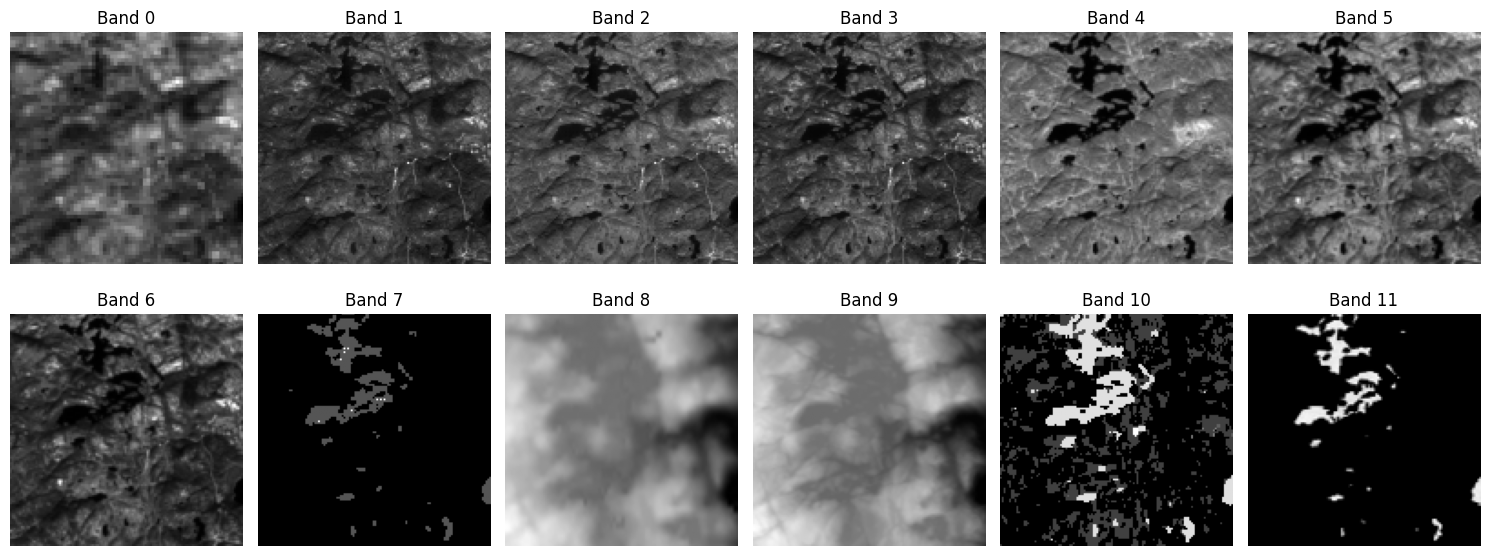

In [104]:
# visualize each band of a sample image
visualize_bands(read_multiband_tif(images_dir / (filenames[0] + ".tif")), max_display=12)

In [105]:
indices = {
    'coastal': 0,
    'blue': 1,
    'green': 2,
    'red': 3,
    'nir': 7,
    'swir1': 10,
    'swir2': 11
}


# Compute normalization stats
full_dataset = MultiBandWaterDataset(
    images_dir=images_dir,
    masks_dir=masks_dir,
    add_features=True,
    feature_indices=indices,
    transform=None
)
mean, std = compute_dataset_stats(full_dataset)
normalize_stats = {"mean": mean, "std": std}
with open('normalize_stats.json', 'w') as f:
    json.dump({"mean": mean.tolist(), "std": std.tolist()}, f)

# Split dataset with stratification
filenames = sorted([p.stem for p in Path(images_dir).glob("*.tif")])
water_ratios, pos_weight = compute_water_ratio(masks_dir, filenames)
labels = [1 if water_ratios.get(name, 0) > 0 else 0 for name in filenames]
train_files, val_files = train_test_split(
    filenames,
    test_size=0.2,
    random_state=123,
    stratify=labels
)
print(f"Total: {len(filenames)} | Train: {len(train_files)} | Val: {len(val_files)}")

# Initialize datasets
train_dataset = MultiBandWaterDataset(
    images_dir=images_dir,
    masks_dir=masks_dir,
    file_list=train_files,
    add_features=True,
    feature_indices=indices,
    normalize_stats=normalize_stats,
    transform=None
)
val_dataset = MultiBandWaterDataset(
    images_dir=images_dir,
    masks_dir=masks_dir,
    file_list=val_files,
    add_features=True,
    feature_indices=indices,
    normalize_stats=normalize_stats,
    transform=None
)
train_ds = train_dataset
val_ds = val_dataset
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

Computing water ratio: 100%|██████████| 306/306 [00:01<00:00, 204.48it/s]

Total: 306 | Train: 244 | Val: 62


In [106]:
# Verify input channels
sample_img, sample_mask = train_dataset[0]
print("Input channels:", sample_img.shape[0])  # Should print 19
print("Mask shape:", sample_mask.shape)

Input channels: 19
Mask shape: torch.Size([1, 128, 128])


In [107]:
all_files = sorted([p.stem for p in images_dir.glob("*.tif")])
count_with_water = sum([read_mask(masks_dir / (f + ".png")).sum() > 0 for f in all_files])
print("Images with water:", count_with_water, "/", len(all_files))

Images with water: 261 / 306


# Unet Model

In [222]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),

        )
    def forward(self, x): return self.net(x)

class Down(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1):
        super().__init__()
        self.mpconv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_ch, out_ch, dropout=dropout)
        )
    def forward(self, x): return self.mpconv(x)

class Up(nn.Module):
    def __init__(self, in_ch, out_ch, bilinear=True, dropout=0.3):
        super().__init__()
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            self.conv = DoubleConv(in_ch, out_ch, dropout=dropout)
        else:
            self.up = nn.ConvTranspose2d(in_ch // 2, in_ch // 2, kernel_size=2, stride=2)
            self.conv = DoubleConv(in_ch, out_ch, dropout=dropout)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class TransUNet(nn.Module):
    def __init__(self, in_ch=22, n_classes=1, base_c=64, bilinear=True, dropout=0.3):
        super().__init__()
        self.inc = DoubleConv(in_ch, base_c, dropout=dropout)
        self.down1 = Down(base_c, base_c*2, dropout=dropout)
        self.down2 = Down(base_c*2, base_c*4, dropout=dropout)
        self.down3 = Down(base_c*4, base_c*8, dropout=dropout)
        factor = 2 if bilinear else 1
        self.down4 = Down(base_c*8, base_c*16 // factor, dropout=dropout)
        self.up1 = Up(base_c*16, base_c*8 // factor, bilinear, dropout=dropout)
        self.up2 = Up(base_c*8, base_c*4 // factor, bilinear, dropout=dropout)
        self.up3 = Up(base_c*4, base_c*2 // factor, bilinear, dropout=dropout)
        self.up4 = Up(base_c*2, base_c, bilinear, dropout=dropout)
        self.outc = nn.Conv2d(base_c, n_classes, 1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        return self.outc(x)

In [223]:
# Get number of input channels from a sample image
sample_img, _ = train_ds[0]  # Unpack only image and mask
in_channels = sample_img.shape[0]
num_channels = sample_img.shape[0]
print("Input channels for model:", in_channels)

Input channels for model: 19


In [224]:
class BCE_Dice_FocalLoss(nn.Module):
    def __init__(self, alpha=0.5, gamma=2.0, bce_weight=1.0, dice_weight=1.0, focal_weight=1.0):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([5.0]))  # boost positives
        self.alpha = alpha
        self.gamma = gamma
        self.bce_w = bce_weight
        self.dice_w = dice_weight
        self.focal_w = focal_weight

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        targets = targets.float()

        # BCE
        bce_loss = self.bce(logits, targets) # pixel-wise BCE

        # Dice
        smooth = 1e-6
        intersection = (probs * targets).sum()
        dice_loss = 1 - (2. * intersection + smooth) / (probs.sum() + targets.sum() + smooth) # optimizes overlap between prediction & ground truth

        # Focal
        pt = torch.where(targets == 1, probs, 1 - probs)
        focal_loss = - (self.alpha * (1 - pt) ** self.gamma * torch.log(pt + smooth)).mean() # focuses on hard examples

        return self.bce_w * bce_loss + self.dice_w * dice_loss + self.focal_w * focal_loss


# Metrics

In [225]:
def compute_metrics(y_pred, y_true, threshold=0.5, smooth=1e-6):
    with torch.no_grad():
        probs = torch.sigmoid(y_pred)
        preds = (probs > threshold).float()
        y_true = y_true.float()

        preds = preds.view(preds.size(0), -1)
        y_true = y_true.view(y_true.size(0), -1)

        tp = (preds * y_true).sum(dim=1)
        fp = (preds * (1 - y_true)).sum(dim=1)
        fn = ((1 - preds) * y_true).sum(dim=1)

        precision = ((tp + smooth) / (tp + fp + smooth)).mean().item()
        recall    = ((tp + smooth) / (tp + fn + smooth)).mean().item()
        f1        = (2 * precision * recall) / (precision + recall + smooth)
        iou       = ((tp + smooth) / (tp + fp + fn + smooth)).mean().item()  # IoU for segmentation to evaluate overlap between prediction & ground truth

        return {
            "precision": precision,
            "recall": recall,
            "f1": f1,   
            "iou": iou
        }


# Training loop

In [235]:
def train_model(model, train_loader, val_loader, optimizer, scheduler, device, filenames, model_name="TransUNet", dataset_name="Dataset", threshold=0.35, epochs=80):
    water_ratios, pos_weight = compute_water_ratio(masks_dir, filenames)
    bce_criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight).to(device))
    dice_criterion = smp.losses.DiceLoss(mode='binary', from_logits=True)
    metrics = {"train": {"Loss": [], "IoU": [], "Accuracy": [], "F1": [], "Precision": [], "Recall": []},
               "val": {"Loss": [], "IoU": [], "Accuracy": [], "F1": [], "Precision": [], "Recall": []}}
    best_iou = 0.0  
    best_state = None

    for epoch in range(epochs):
        criterion = bce_criterion if epoch < 40 else dice_criterion
        model.train()
        train_loss = 0
        train_iou = 0
        train_acc = 0
        train_f1 = 0
        train_precision = 0
        train_recall = 0
        train_batches = 0

        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)
            optimizer.zero_grad()
            outputs = model(images)  # Shape: [batch_size, 1, 128, 128]
            loss = criterion(outputs, masks)  # Shapes now match: [batch_size, 1, 128, 128]
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            preds = torch.sigmoid(outputs) > threshold
            train_iou += jaccard_score(masks.cpu().numpy().flatten(), preds.cpu().numpy().flatten(), average='binary')
            train_acc += accuracy_score(masks.cpu().numpy().flatten(), preds.cpu().numpy().flatten())
            train_f1 += f1_score(masks.cpu().numpy().flatten(), preds.cpu().numpy().flatten(), average='binary')
            train_precision += precision_score(masks.cpu().numpy().flatten(), preds.cpu().numpy().flatten(), average='binary', zero_division=0)  # Added zero_division
            train_recall += recall_score(masks.cpu().numpy().flatten(), preds.cpu().numpy().flatten(), average='binary')
            train_batches += 1

        train_loss /= len(train_loader.dataset)
        train_iou /= train_batches
        train_acc /= train_batches
        train_f1 /= train_batches
        train_precision /= train_batches
        train_recall /= train_batches

        model.eval()
        val_loss = 0
        val_iou = 0
        val_acc = 0
        val_f1 = 0
        val_precision = 0
        val_recall = 0
        val_batches = 0

        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)
                outputs = model(images)
                loss = criterion(outputs, masks)
                val_loss += loss.item() * images.size(0)
                preds = torch.sigmoid(outputs) > threshold
                val_iou += jaccard_score(masks.cpu().numpy().flatten(), preds.cpu().numpy().flatten(), average='binary')
                val_acc += accuracy_score(masks.cpu().numpy().flatten(), preds.cpu().numpy().flatten())
                val_f1 += f1_score(masks.cpu().numpy().flatten(), preds.cpu().numpy().flatten(), average='binary')
                val_precision += precision_score(masks.cpu().numpy().flatten(), preds.cpu().numpy().flatten(), average='binary', zero_division=0)  # Added zero_division
                val_recall += recall_score(masks.cpu().numpy().flatten(), preds.cpu().numpy().flatten(), average='binary')
                val_batches += 1

        val_loss /= len(val_loader.dataset)
        val_iou /= val_batches
        val_acc /= val_batches
        val_f1 /= val_batches
        val_precision /= val_batches
        val_recall /= val_batches

        metrics["train"]["Loss"].append(train_loss)
        metrics["train"]["IoU"].append(train_iou)
        metrics["train"]["Accuracy"].append(train_acc)
        metrics["train"]["F1"].append(train_f1)
        metrics["train"]["Precision"].append(train_precision)
        metrics["train"]["Recall"].append(train_recall)
        metrics["val"]["Loss"].append(val_loss)
        metrics["val"]["IoU"].append(val_iou)
        metrics["val"]["Accuracy"].append(val_acc)
        metrics["val"]["F1"].append(val_f1)
        metrics["val"]["Precision"].append(val_precision)
        metrics["val"]["Recall"].append(val_recall)

        logging.info(f"Epoch {epoch+1}/{epochs} - {model_name} ({dataset_name})")
        logging.info(f"Train - Loss: {train_loss:.4f}, IoU: {train_iou:.4f}, Accuracy: {train_acc:.4f}, "
                     f"F1: {train_f1:.4f}, Precision: {train_precision:.4f}, Recall: {train_recall:.4f}")
        logging.info(f"Val   - Loss: {val_loss:.4f}, IoU: {val_iou:.4f}, Accuracy: {val_acc:.4f}, "
                     f"F1: {val_f1:.4f}, Precision: {val_precision:.4f}, Recall: {val_recall:.4f}")

        scheduler.step(val_loss)

        if val_iou > best_iou: 
            best_iou = val_iou
            best_state = model.state_dict()
            torch.save(best_state, f"best_{model_name}_{dataset_name}.pth")
            logging.info(f"New best validation IoU: {best_iou:.4f} - Saved best model")

    metrics["train"] = {k: max(v) if k != "Loss" else min(v) for k, v in metrics["train"].items()}
    metrics["val"] = {k: max(v) if k != "Loss" else min(v) for k, v in metrics["val"].items()}
    return metrics, best_state

In [236]:
def evaluate_model(model, loader, model_name, dataset_name, threshold=0.5):
    model.eval()
    iou = 0
    accuracy = 0
    f1 = 0
    precision = 0
    recall = 0
    loss = 0
    criterion = nn.BCEWithLogitsLoss()  # No pos_weight for evaluation
    batches = 0

    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss += criterion(outputs, masks).item() * images.size(0)
            preds = torch.sigmoid(outputs) > threshold
            iou += jaccard_score(masks.cpu().numpy().flatten(), preds.cpu().numpy().flatten(), average='binary')
            accuracy += accuracy_score(masks.cpu().numpy().flatten(), preds.cpu().numpy().flatten())
            f1 += f1_score(masks.cpu().numpy().flatten(), preds.cpu().numpy().flatten(), average='binary')
            precision += precision_score(masks.cpu().numpy().flatten(), preds.cpu().numpy().flatten(), average='binary')
            recall += recall_score(masks.cpu().numpy().flatten(), preds.cpu().numpy().flatten(), average='binary')
            batches += 1

    loss /= len(loader.dataset)
    iou /= batches
    accuracy /= batches
    f1 /= batches
    precision /= batches
    recall /= batches

    logging.info(f"Final Evaluation for {model_name} on {dataset_name}:")
    logging.info(f"Loss: {loss:.4f}, IoU: {iou:.4f}, Accuracy: {accuracy:.4f}, F1: {f1:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}")
    return {"Loss": loss, "IoU": iou, "Accuracy": accuracy, "F1": f1, "Precision": precision, "Recall": recall}

In [237]:

warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

In [238]:
import logging
# Ensure logging to console with INFO level
logging.getLogger().handlers = []  # Clear any existing handlers to avoid conflicts
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[logging.StreamHandler()]  # Force console output
)

# Initialize model, optimizer, and scheduler
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TransUNet(in_ch=19, n_classes=1, base_c=32, dropout=0.2).to(device)
optimizer = Adam(model.parameters(), lr=1e-3)
scheduler = ReduceLROnPlateau(optimizer, mode="min", patience=5, factor=0.5)

# Verify DataLoaders
print(f"Train loader batches: {len(train_loader)}", flush=True)
print(f"Validation loader batches: {len(val_loader)}", flush=True)
if len(train_loader) == 0 or len(val_loader) == 0:
    raise ValueError("Empty DataLoader detected. Check dataset and loader configuration.")

# Verify logging level
print(f"Logging level: {logging.getLogger().level} (should be 20 for INFO)", flush=True)

# Train model with logging
print("Starting training...", flush=True)
logging.info("Starting training...")
metrics, best_state = train_model(model, train_loader, val_loader, optimizer, scheduler, device, 
                                 filenames=train_ds.filenames, model_name="TransUNet", 
                                 dataset_name="Dataset", threshold=0.35, epochs=80)
print(f"Training completed. Metrics: {metrics}", flush=True)
logging.info("Training completed. Metrics: %s", metrics)

# Save the best model state
torch.save(best_state, "best_TransUNet_Dataset.pth")
print("Saved best model to best_TransUNet_Dataset.pth", flush=True)
logging.info("Saved best model to best_TransUNet_Dataset.pth")

Train loader batches: 31
Validation loader batches: 8
Logging level: 20 (should be 20 for INFO)
Starting training...


2025-09-29 16:59:44,332 - INFO - Starting training...
Computing water ratio: 100%|██████████| 244/244 [00:00<00:00, 248.12it/s]
2025-09-29 16:59:54,672 - INFO - Epoch 1/80 - TransUNet (Dataset)
2025-09-29 16:59:54,673 - INFO - Train - Loss: 1.0194, IoU: 0.2429, Accuracy: 0.2457, F1: 0.3835, Precision: 0.2433, Recall: 0.9947
2025-09-29 16:59:54,674 - INFO - Val   - Loss: 1.1501, IoU: 0.3075, Accuracy: 0.3075, F1: 0.4644, Precision: 0.3075, Recall: 0.9995
2025-09-29 16:59:54,777 - INFO - New best validation IoU: 0.3075 - Saved best model
2025-09-29 17:00:04,559 - INFO - Epoch 2/80 - TransUNet (Dataset)
2025-09-29 17:00:04,560 - INFO - Train - Loss: 0.8571, IoU: 0.2795, Accuracy: 0.3881, F1: 0.4262, Precision: 0.2921, Recall: 0.9447
2025-09-29 17:00:04,560 - INFO - Val   - Loss: 1.0346, IoU: 0.3106, Accuracy: 0.3194, F1: 0.4682, Precision: 0.3106, Recall: 1.0000
2025-09-29 17:00:04,663 - INFO - New best validation IoU: 0.3106 - Saved best model
2025-09-29 17:00:14,377 - INFO - Epoch 3/80 

Training completed. Metrics: {'train': {'Loss': 0.31352629817900113, 'IoU': 0.5946893926889193, 'Accuracy': 0.8590287239320816, 'F1': 0.7352239533236691, 'Precision': 0.679372688893258, 'Recall': 0.9946989050464147}, 'val': {'Loss': 0.2853829264640808, 'IoU': 0.6720512425631208, 'Accuracy': 0.889556884765625, 'F1': 0.8011044643509504, 'Precision': 0.9629621239103738, 'Recall': 1.0}}


2025-09-29 17:11:29,401 - INFO - Training completed. Metrics: {'train': {'Loss': 0.31352629817900113, 'IoU': 0.5946893926889193, 'Accuracy': 0.8590287239320816, 'F1': 0.7352239533236691, 'Precision': 0.679372688893258, 'Recall': 0.9946989050464147}, 'val': {'Loss': 0.2853829264640808, 'IoU': 0.6720512425631208, 'Accuracy': 0.889556884765625, 'F1': 0.8011044643509504, 'Precision': 0.9629621239103738, 'Recall': 1.0}}


Saved best model to best_TransUNet_Dataset.pth


2025-09-29 17:11:29,520 - INFO - Saved best model to best_TransUNet_Dataset.pth


In [239]:
eval_metrics = evaluate_model(model, val_loader, "TransUNet", "Dataset")
logging.info(f"TransUNet Evaluation Metrics: {eval_metrics}")

2025-09-29 17:21:42,670 - INFO - Final Evaluation for TransUNet on Dataset:
2025-09-29 17:21:42,672 - INFO - Loss: 0.3588, IoU: 0.6156, Accuracy: 0.8765, F1: 0.7566, Precision: 0.9228, Recall: 0.6574
2025-09-29 17:21:42,673 - INFO - TransUNet Evaluation Metrics: {'Loss': 0.3587861051482539, 'IoU': 0.6155529287168429, 'Accuracy': 0.876514752705892, 'F1': 0.7565885775586034, 'Precision': 0.9228025051778412, 'Recall': 0.6573974534272502}


# Visualize sample predictions

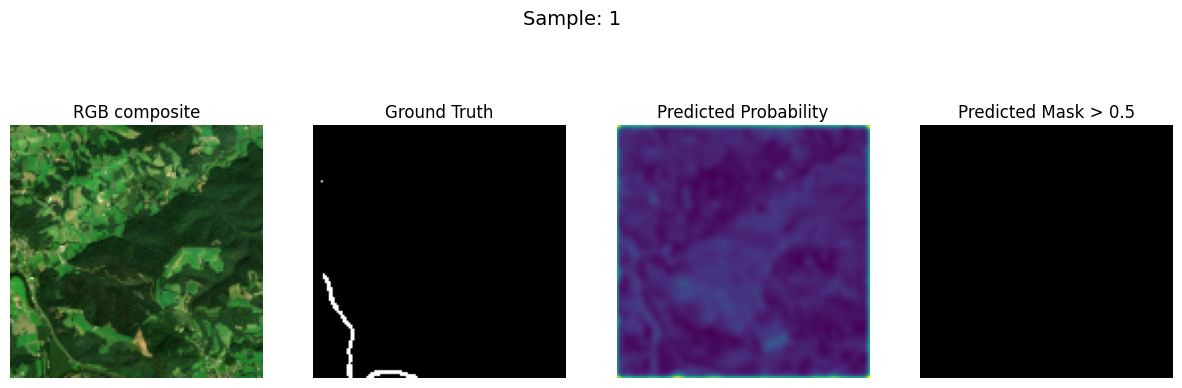

In [240]:
def show_prediction(model, dataset, idx=0, threshold=0.5, band_indices={'red': 3, 'green': 2, 'blue': 1}):
    model.eval()
    img, mask = dataset[idx]  # Expect only img, mask from dataset
    name = dataset.filenames[idx]  # Get name from dataset.filenames
    img_t = img.unsqueeze(0).to(device)
    with torch.no_grad():
        pred = torch.sigmoid(model(img_t))[0, 0].cpu().numpy()
    pred_bin = (pred > threshold).astype(np.uint8)
    mask = mask.squeeze().numpy()  # Squeeze channel dimension before converting to numpy
    
    # Try to construct RGB if possible
    C, H, W = img.shape
    rgb = None
    if all(k in band_indices for k in ('red', 'green', 'blue')):
        if band_indices['red'] < C and band_indices['green'] < C and band_indices['blue'] < C:
            r = img[band_indices['red']].numpy()
            g = img[band_indices['green']].numpy()
            b = img[band_indices['blue']].numpy()
            rgb = np.stack([r, g, b], axis=-1)
            rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-9)
    
    # Plot
    plt.figure(figsize=(15, 5))
    if rgb is not None:
        plt.subplot(1, 4, 1)
        plt.imshow(rgb)
        plt.title("RGB composite")
        plt.axis("off")
    else:
        plt.subplot(1, 4, 1)
        plt.imshow(img[0], cmap="gray")
        plt.title("Band 0")
        plt.axis("off")
    plt.subplot(1, 4, 2)
    plt.imshow(mask, cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")
    plt.subplot(1, 4, 3)
    plt.imshow(pred, cmap="viridis")
    plt.title("Predicted Probability")
    plt.axis("off")
    plt.subplot(1, 4, 4)
    plt.imshow(pred_bin, cmap="gray")
    plt.title(f"Predicted Mask > {threshold}")
    plt.axis("off")
    plt.suptitle(f"Sample: {name}", fontsize=14)
    plt.show()

# Example usage: show a sample from validation set
show_prediction(model, val_ds, idx=0)

# Visualization Function

In [241]:
def visualize_prediction(model, dataset, idx=0):
    model.eval()
    X, y_true = dataset[idx]
    with torch.no_grad():
        X = X.unsqueeze(0).to(device)
        y_pred = model(X).cpu().squeeze().numpy()

    fig, ax = plt.subplots(1, 3, figsize=(12, 4))
    ax[0].imshow(X.cpu().squeeze()[0], cmap="gray")  
    ax[0].set_title("Input (Band 1)")
    ax[1].imshow(y_true.squeeze(), cmap="gray")
    ax[1].set_title("Ground Truth")
    ax[2].imshow(y_pred > 0.5, cmap="gray")
    ax[2].set_title("Prediction")
    plt.show()

# Show multiple validation samples

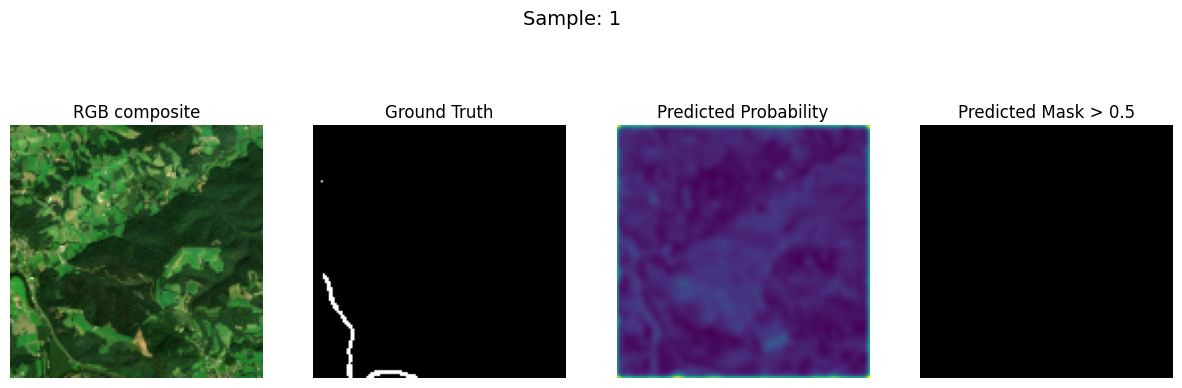

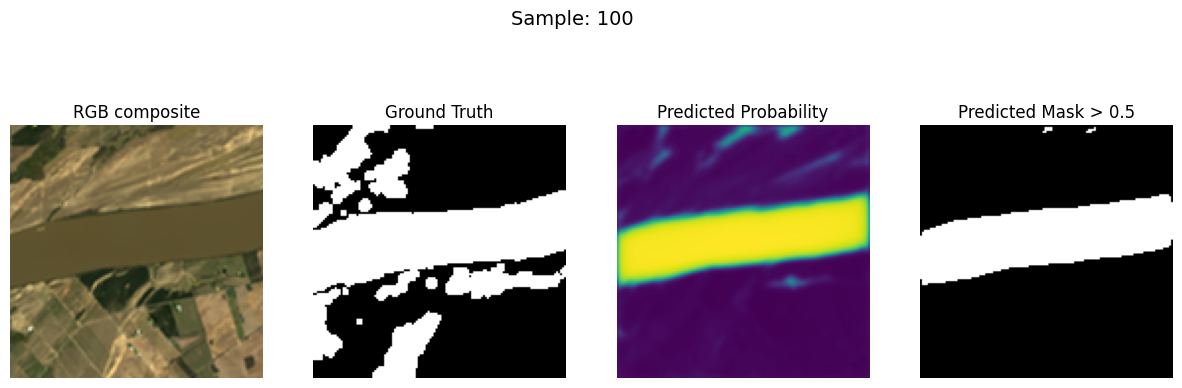

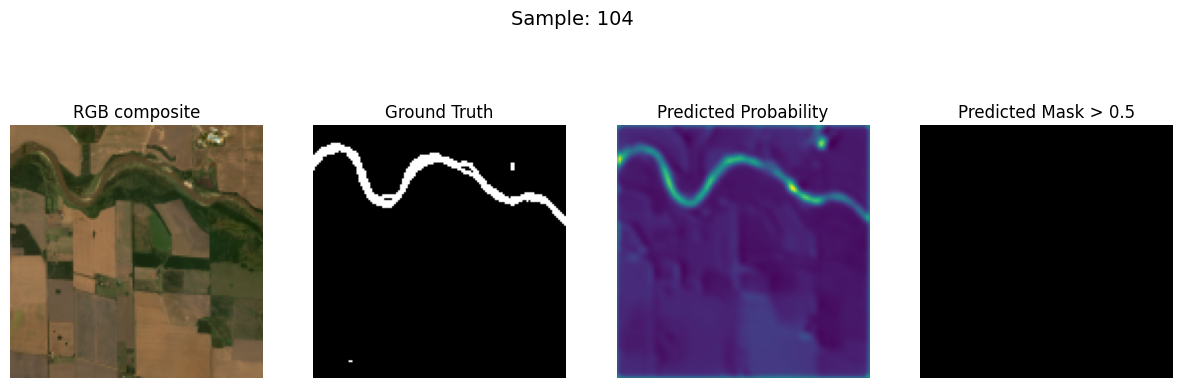

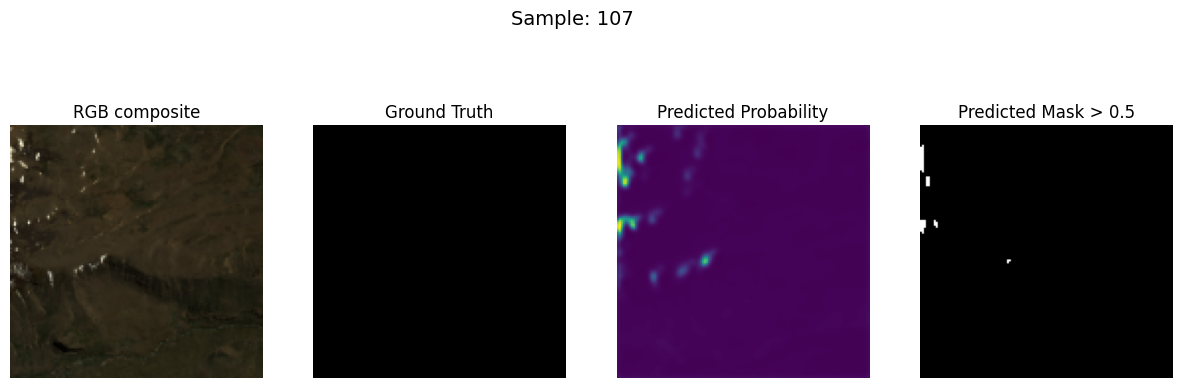

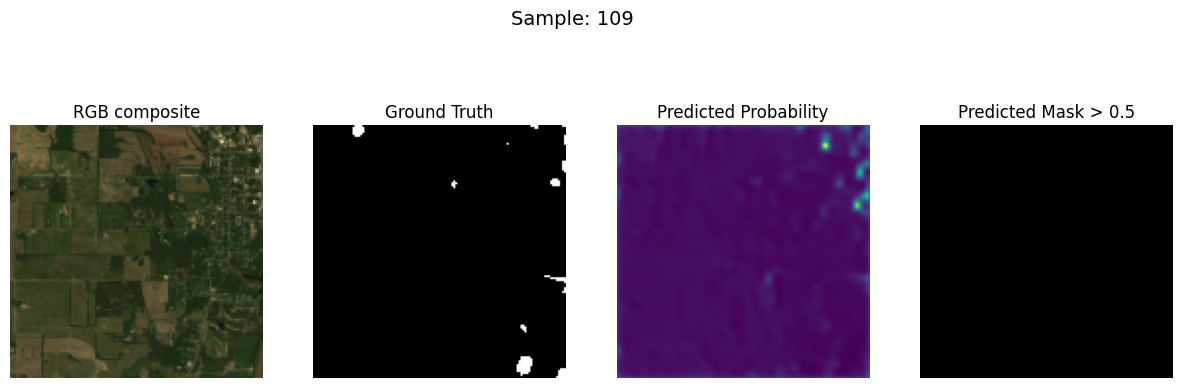

In [242]:
for i in range(min(5, len(val_ds))):  
    show_prediction(model, val_ds, idx=i)

# Inspect band contributions

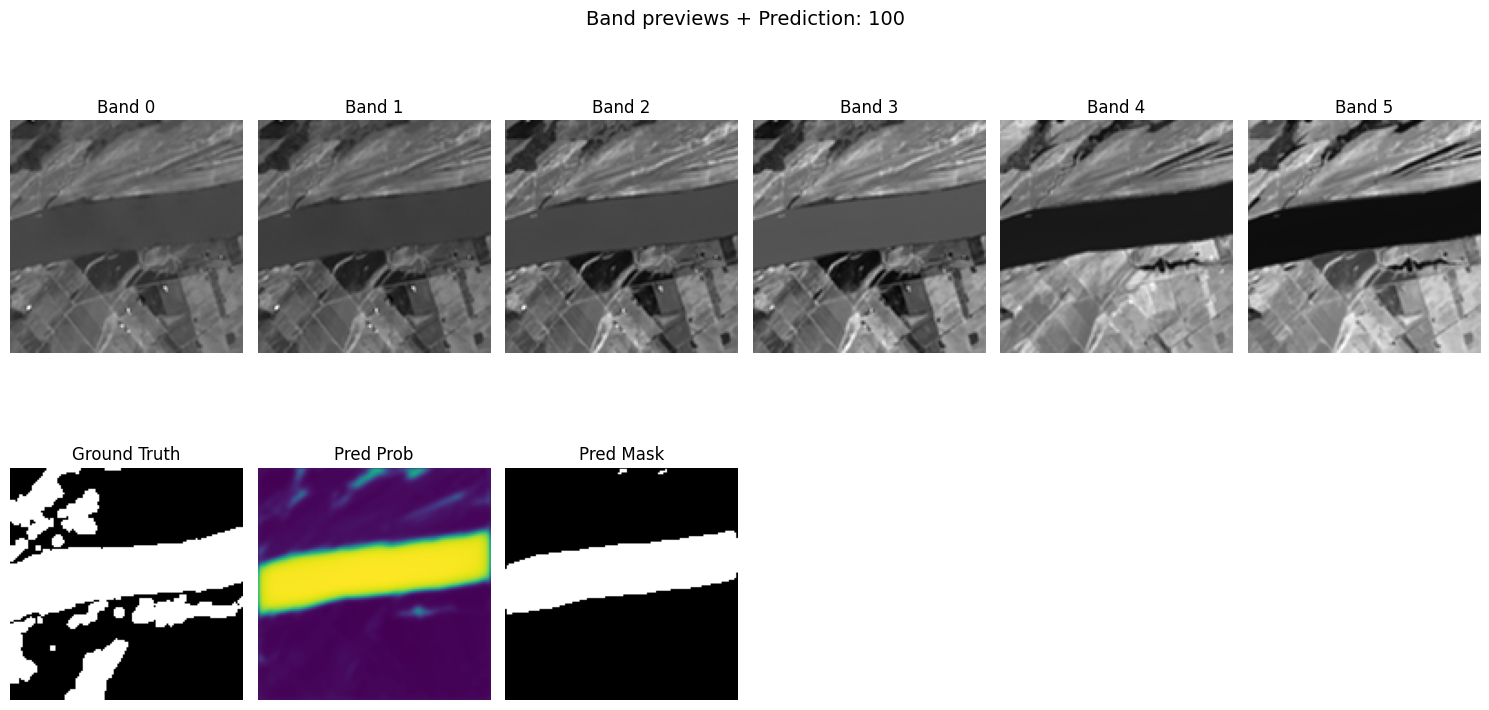

In [243]:
def show_bands_with_prediction(model, dataset, idx=0, max_bands=6, threshold=0.5):
    model.eval()
    img, mask = dataset[idx]  # Expect only img, mask from dataset
    name = dataset.filenames[idx]  # Get name from dataset.filenames
    img_t = img.unsqueeze(0).to(device)
    with torch.no_grad():
        pred = torch.sigmoid(model(img_t))[0, 0].cpu().numpy()
    pred_bin = (pred > threshold).astype(np.uint8)
    
    C, H, W = img.shape
    n = min(C, max_bands)
    plt.figure(figsize=(15, 8))
    for i in range(n):
        plt.subplot(2, n, i+1)
        plt.imshow(img[i], cmap="gray")
        plt.title(f"Band {i}")
        plt.axis("off")
    plt.subplot(2, n, n+1)
    plt.imshow(mask.squeeze().numpy(), cmap="gray")  # Squeeze mask to 2D
    plt.title("Ground Truth")
    plt.axis("off")
    plt.subplot(2, n, n+2)
    plt.imshow(pred, cmap="viridis")
    plt.title("Pred Prob")
    plt.axis("off")
    plt.subplot(2, n, n+3)
    plt.imshow(pred_bin, cmap="gray")
    plt.title("Pred Mask")
    plt.axis("off")
    plt.suptitle(f"Band previews + Prediction: {name}", fontsize=14)
    plt.tight_layout()
    plt.show()

# Example usage
show_bands_with_prediction(model, val_ds, idx=1)

# Confusion Matrix on Validation Set

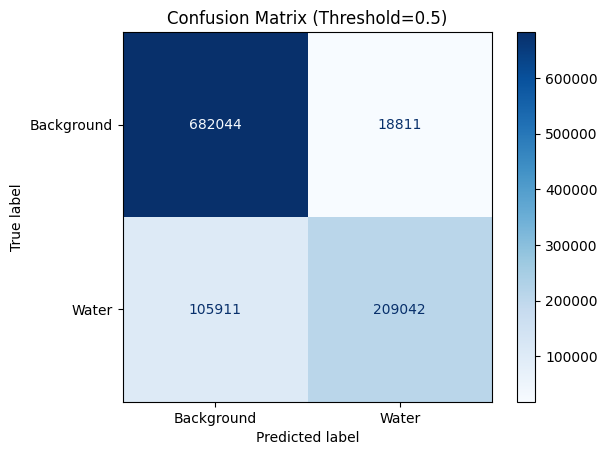

In [244]:
def evaluate_confusion_matrix(model, loader, device, threshold=0.5):
    y_true, y_pred = [], []
    model.eval()
    with torch.no_grad():
        for imgs, masks in loader:  # Changed to expect only imgs, masks
            imgs = imgs.to(device)
            masks = masks.to(device).view(-1).cpu().numpy()
            preds = torch.sigmoid(model(imgs)).view(-1).cpu().numpy()
            preds_bin = (preds > threshold).astype(int)
            y_true.extend(masks.tolist())
            y_pred.extend(preds_bin.tolist())
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Background", "Water"])
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix (Threshold={threshold})")
    plt.show()

# Example usage
evaluate_confusion_matrix(model, val_loader, device, threshold=0.5)

# ROC Curve on Validation Set

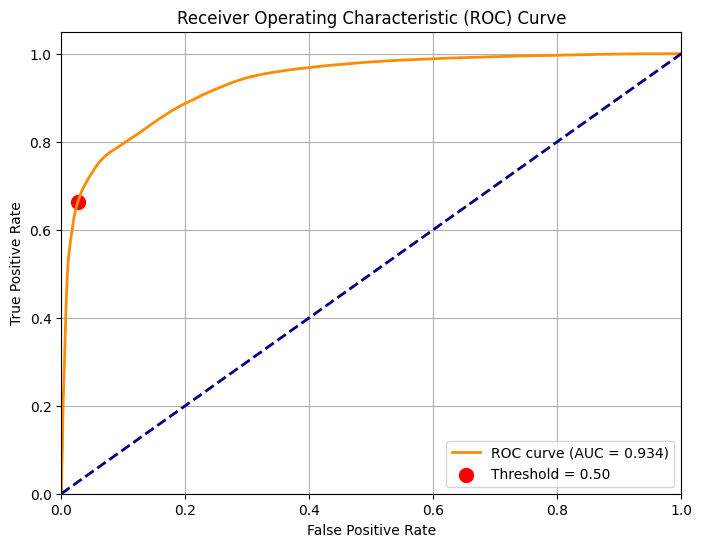

In [246]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

def plot_roc_curve(model, loader, device, threshold=0.5):
    model.eval()
    y_true, y_scores = [], []
    with torch.no_grad():
        for imgs, masks in loader:  # Expect img, mask from loader
            imgs = imgs.to(device)
            masks = masks.to(device).view(-1).cpu().numpy()  # Flatten masks
            scores = torch.sigmoid(model(imgs)).view(-1).cpu().numpy()  # Flatten probabilities
            y_true.extend(masks.tolist())
            y_scores.extend(scores.tolist())
    
    # Compute ROC curve
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    
    # Find closest threshold point
    idx = (abs(thresholds - threshold)).argmin()
    threshold_fpr = fpr[idx]
    threshold_tpr = tpr[idx]
    
    # Plot ROC curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.scatter([threshold_fpr], [threshold_tpr], color='red', s=100, label=f'Threshold = {threshold:.2f}')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

# Example usage
plot_roc_curve(model, val_loader, device, threshold=0.5)  # Corrected typo

# Precision-Recall (PR) Curve on Validation Set

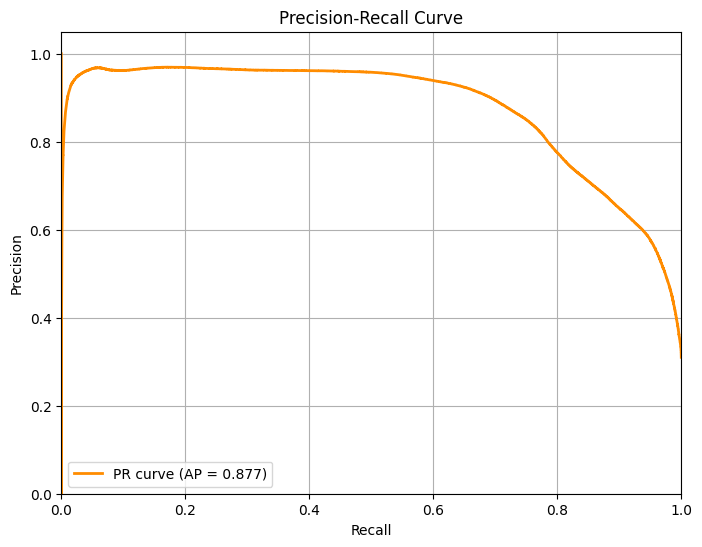

In [248]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

def plot_pr_curve(model, loader, device):
    model.eval()
    y_true, y_scores = [], []
    with torch.no_grad():
        for imgs, masks in loader:  # Changed to expect only imgs, masks
            imgs = imgs.to(device)
            masks = masks.to(device).view(-1).cpu().numpy()  # Flatten masks
            scores = torch.sigmoid(model(imgs)).view(-1).cpu().numpy()  # Flatten probabilities
            y_true.extend(masks.tolist())
            y_scores.extend(scores.tolist())
    
    # Compute Precision-Recall curve
    precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
    ap = average_precision_score(y_true, y_scores)
    
    # Plot PR curve
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, color='darkorange', lw=2, label=f'PR curve (AP = {ap:.3f})')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc='lower left')
    plt.grid(True)
    plt.show()

# Example usage
plot_pr_curve(model, val_loader, device)

# Overlay Predicted Mask on RGB

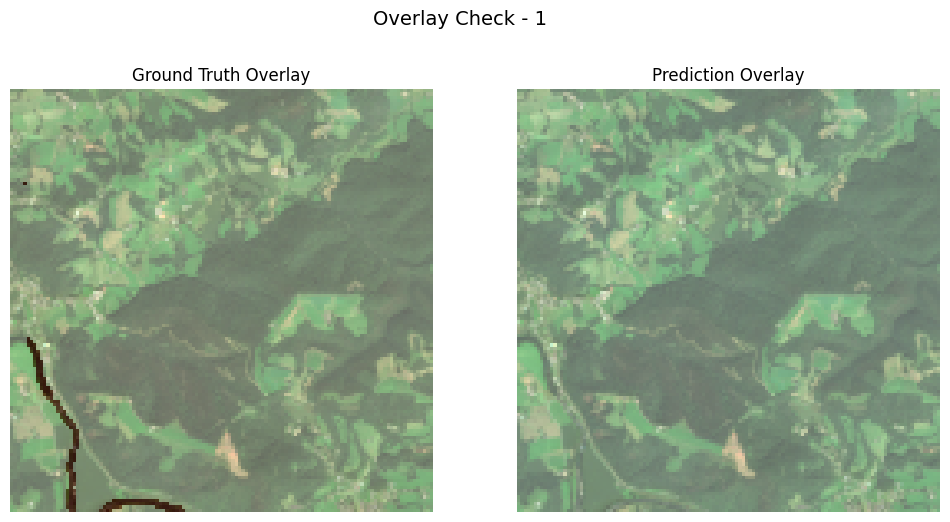

In [250]:
def overlay_prediction(model, dataset, idx=0, threshold=0.5, band_indices={'red': 3, 'green': 2, 'blue': 1}):
    model.eval()
    img, mask = dataset[idx]  # Changed to expect only img, mask
    name = dataset.filenames[idx]  # Get name from dataset.filenames
    img_t = img.unsqueeze(0).to(device)
    with torch.no_grad():
        pred = torch.sigmoid(model(img_t))[0, 0].cpu().numpy()
    pred_bin = (pred > threshold).astype(np.uint8)
    mask = mask.squeeze().numpy()  # Squeeze channel dimension

    # Build RGB composite
    C, H, W = img.shape
    rgb = None
    if all(k in band_indices for k in ('red', 'green', 'blue')):
        if band_indices['red'] < C and band_indices['green'] < C and band_indices['blue'] < C:
            r, g, b = img[band_indices['red']], img[band_indices['green']], img[band_indices['blue']]
            rgb = np.stack([r, g, b], axis=-1)
            rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-9)
    
    if rgb is None:
        print("Could not construct RGB, using Band 0 as grayscale.")
        rgb = np.repeat(img[0][..., None], 3, axis=-1)

    # Overlay (Ground Truth vs Prediction)
    plt.figure(figsize=(12, 6))
    
    # Ground Truth Overlay
    plt.subplot(1, 2, 1)
    plt.imshow(rgb)
    plt.imshow(mask, cmap="Reds", alpha=0.4)
    plt.title("Ground Truth Overlay")
    plt.axis("off")
    
    # Predicted Overlay
    plt.subplot(1, 2, 2)
    plt.imshow(rgb)
    plt.imshow(pred_bin, cmap="Blues", alpha=0.4)
    plt.title("Prediction Overlay")
    plt.axis("off")
    
    plt.suptitle(f"Overlay Check - {name}", fontsize=14)
    plt.show()

# Example usage
overlay_prediction(model, val_ds, idx=0)

# IoU/F1 vs Threshold Plot

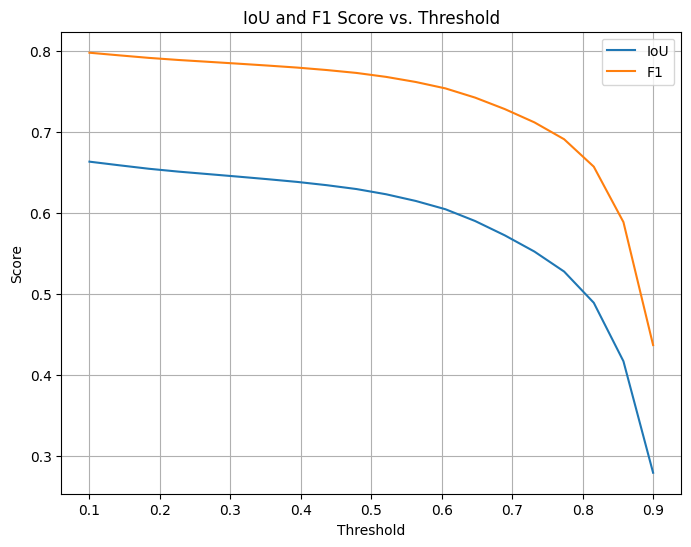

In [251]:
def plot_iou_f1_vs_threshold(model, loader, device):
    y_true, y_score = [], []
    model.eval()
    with torch.no_grad():
        for imgs, masks in loader:  # Changed to expect only imgs, masks
            imgs = imgs.to(device)
            masks = masks.to(device).view(-1).cpu().numpy()
            preds = torch.sigmoid(model(imgs)).view(-1).cpu().numpy()
            y_true.extend(masks.tolist())
            y_score.extend(preds.tolist())
    if sum(y_true) == 0:
        print("No water samples in val set—plot invalid.")
    else:
        thresholds = np.linspace(0.1, 0.9, 20)
        ious, f1s = [], []
        for th in thresholds:
            preds_bin = (np.array(y_score) > th).astype(int)
            cm = confusion_matrix(y_true, preds_bin)
            tn, fp, fn, tp = cm.ravel()
            iou_val = tp / (tp + fn + fp + 1e-6)
            f1_val = (2 * tp) / (2 * tp + fn + fp + 1e-6)
            ious.append(iou_val)
            f1s.append(f1_val)
        plt.figure(figsize=(8, 6))  # Added for consistent plot size
        plt.plot(thresholds, ious, label="IoU")
        plt.plot(thresholds, f1s, label="F1")
        plt.xlabel("Threshold")
        plt.ylabel("Score")
        plt.title("IoU and F1 Score vs. Threshold")
        plt.legend()
        plt.grid(True)  # Added for better readability
        plt.show()

# Example usage
plot_iou_f1_vs_threshold(model, val_loader, device)

# Deployment

In [252]:


if 'normalize_stats' in globals():
    with open('normalize_stats.json', 'w') as f:
        json.dump({'mean': normalize_stats['mean'].tolist(), 'std': normalize_stats['std'].tolist()}, f)
    print("Saved normalize_stats to normalize_stats.json")
else:
    print("normalize_stats not defined. Recompute with compute_dataset_stats(full_dataset).")

Saved normalize_stats to normalize_stats.json


In [254]:
# Cell 1: Select and Save Best Model from This Notebook
import json
import torch

# Assuming eval_metrics is a dict like {'IoU': 0.XX, 'F1': 0.XX, 'Precision': 0.XX, 'Recall': 0.XX}
best_baseline_metrics = eval_metrics  # Replace with your actual eval dict
best_baseline_iou = best_baseline_metrics.get('IoU', 0.0)

# Save the model
model_path = "best_baseline_model.pth"
torch.save(model.state_dict(), model_path)
print(f"Saved best baseline model to {model_path}")

# Save metrics and stats (using your existing normalize_stats)
stats = {
    'metrics': best_baseline_metrics,
    'normalize_stats': {
        'mean': normalize_stats['mean'].tolist(),
        'std': normalize_stats['std'].tolist()
    },
    'feature_indices': indices,  # Your band indices dict
    'in_channels': 22  # From your notebook (adjust if needed)
}
with open('baseline_model_stats.json', 'w') as f:
    json.dump(stats, f)
print("Saved baseline model stats to baseline_model_stats.json")

# Print summary
print(f"Best Baseline Model IoU={best_baseline_iou:.4f}")

Saved best baseline model to best_baseline_model.pth
Saved baseline model stats to baseline_model_stats.json
Best Baseline Model IoU=0.6156
